# YZM0206 Laboratuvar 6 Uygulaması - Evrişimli Sinir Ağları (CNN)

## ADIM 1: Veri Kümesi Anatomisi ve Normalizasyon

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # TensorFlow uyarılarını gizler

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10
from sklearn.metrics import confusion_matrix

# Veri setlerinin yüklenmesi
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = fashion_mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

print("--- Veri Setleri Orijinal Boyutları ---")
print(f"MNIST Eğitim Seti: {x_train_mnist.shape}")
print(f"Fashion-MNIST Eğitim Seti: {x_train_fmnist.shape}")
print(f"CIFAR-10 Eğitim Seti: {x_train_cifar.shape}")

# Keras CNN modelleri giriş olarak (Batch, Height, Width, Channels) bekler.
# MNIST ve Fashion-MNIST için kanal boyutunu ekliyoruz ve normalizasyon yapıyoruz.
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1).astype("float32") / 255.0

x_train_fmnist = x_train_fmnist.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test_fmnist = x_test_fmnist.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# CIFAR-10 zaten renkli (3 kanallı), sadece normalizasyon yapıyoruz.
x_train_cifar = x_train_cifar.astype("float32") / 255.0
x_test_cifar = x_test_cifar.astype("float32") / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 193s 1us/step
--- Veri Setleri Orijinal Boyutları ---
MNIST Eğitim Seti: (60000, 28, 28)
Fashion-MNIST Eğitim Seti: (60000, 28, 28)
CIFAR-10 Eğitim Seti: (50000, 32, 32, 3)


## ADIM 2: Conv2D ve Padding Stratejileri (Aritmetik Analiz)

In [2]:
# 1. Durum: 28x28x1 giriş, 3x3 kernel, Stride 1, Padding 'valid'
model1 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding='valid')
], name="Model_1_Valid_Padding")

# 2. Durum: 28x28x1 giriş, 3x3 kernel, Stride 1, Padding 'same'
model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding='same')
], name="Model_2_Same_Padding")

# 3. Durum: 32x32x3 giriş, 5x5 kernel, Stride 2, Padding 'valid'
model3 = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(filters=16, kernel_size=(5, 5), strides=2, padding='valid')
], name="Model_3_Stride_2_Valid_Padding")

print("--- Durum 1 Özeti ---")
model1.summary()
print("\n--- Durum 2 Özeti ---")
model2.summary()
print("\n--- Durum 3 Özeti ---")
model3.summary()


--- Durum 1 Özeti ---


Model: "Model_1_Valid_Padding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160 (640.00 B)

 Trainable params: 160 (640.00 B)

...

Model: "Model_3_Stride_2_Valid_Padding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 16)     │         1,216 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,216 (4.75 KB)

 Trainable params: 1,216 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

## ADIM 3: Pooling vs. Stride 2 (Bilgi Azaltma)

In [3]:
# MaxPooling ile boyut küçültme modeli
model_pool = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2))
], name="Model_Pooling")

# Stride=2 ile boyut küçültme modeli
model_stride = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), strides=2, padding='same', activation='relu')
], name="Model_Stride2")

print("--- MaxPooling ile Boyut Küçültme ---")
model_pool.summary()
print("\n--- Stride=2 ile Boyut Küçültme ---")
model_stride.summary()


--- MaxPooling ile Boyut Küçültme ---


Model: "Model_Pooling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

...

Model: "Model_Stride2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

## ADIM 4: Uçtan Uca Sınıflandırma (Fashion-MNIST)

--- Model Eğitimi Başlıyor (Fashion-MNIST) ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 68s 78ms/step - accuracy: 0.8483 - loss: 0.4220 - val_accuracy: 0.8932 - val_loss: 0.3029
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 74ms/step - accuracy: 0.9005 - loss: 0.2748 - val_accuracy: 0.8965 - val_loss: 0.2848
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 72ms/step - accuracy: 0.9174 - loss: 0.2249 - val_accuracy: 0.9123 - val_loss: 0.2501
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.9295 - loss: 0.1907 - val_accuracy: 0.9162 - val_loss: 0.2308
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.9407 - loss: 0.1601 - val_accuracy: 0.9153 - val_loss: 0.2233
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


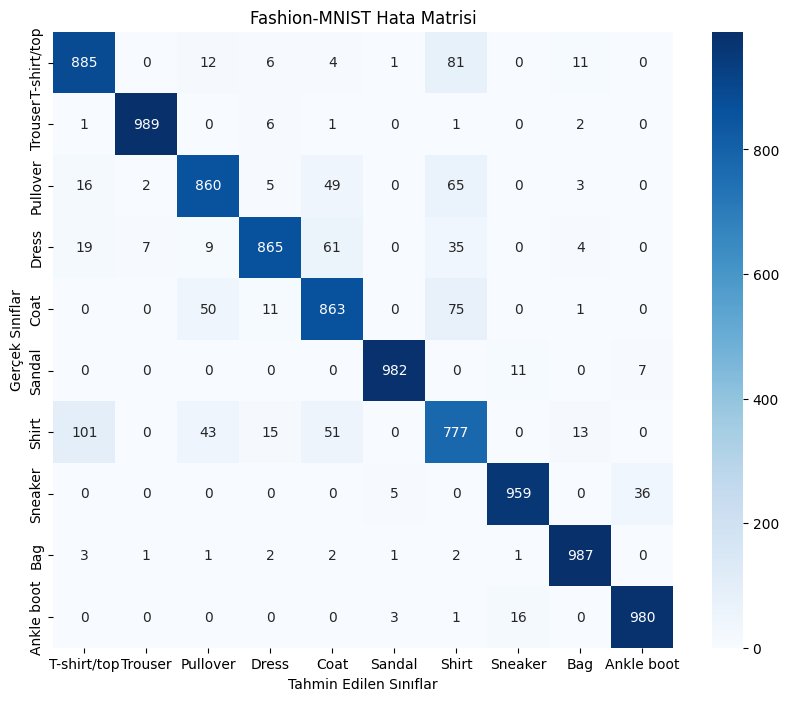

In [4]:
# Uçtan uca mimarinin kurulması
model_fmnist = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Modelin derlenmesi
model_fmnist.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

print("--- Model Eğitimi Başlıyor (Fashion-MNIST) ---")
# Hızlı sonuç almak için 5 epoch eğitiyoruz
history = model_fmnist.fit(x_train_fmnist, y_train_fmnist, epochs=5, validation_split=0.1, batch_size=64)

# Tahminlerin alınması ve Hata Matrisi (Confusion Matrix) çizimi
y_pred_probs = model_fmnist.predict(x_test_fmnist)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test_fmnist, y_pred)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen Sınıflar')
plt.ylabel('Gerçek Sınıflar')
plt.title('Fashion-MNIST Hata Matrisi')
plt.show()


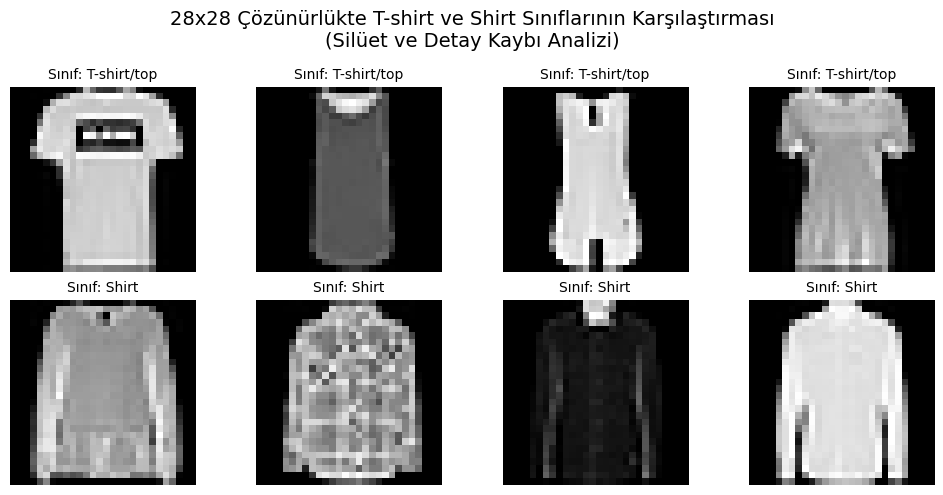

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# 1. Veri setini yükleyelim
(x_train, y_train), (_, _) = fashion_mnist.load_data()

# 2. 'T-shirt/top' (Sınıf 0) ve 'Shirt' (Sınıf 6) indekslerini bulalım
tshirt_indices = np.where(y_train == 0)[0]
shirt_indices = np.where(y_train == 6)[0]

# 3. Her iki sınıftan rastgele 4'er adet örnek alalım
num_samples = 4
selected_tshirts = x_train[tshirt_indices[:num_samples]]
selected_shirts = x_train[shirt_indices[:num_samples]]

# 4. Yan yana ızgara (grid) şeklinde görselleştirelim
fig, axes = plt.subplots(2, num_samples, figsize=(10, 5))

for i in range(num_samples):
    # Üst satıra Tişörtleri çizdir
    axes[0, i].imshow(selected_tshirts[i], cmap='gray')
    axes[0, i].set_title("Sınıf: T-shirt/top", fontsize=10)
    axes[0, i].axis('off')

    # Alt satıra Gömlekleri çizdir
    axes[1, i].imshow(selected_shirts[i], cmap='gray')
    axes[1, i].set_title("Sınıf: Shirt", fontsize=10)
    axes[1, i].axis('off')

# Başlık ve format ayarları
plt.suptitle("28x28 Çözünürlükte T-shirt ve Shirt Sınıflarının Karşılaştırması\n(Silüet ve Detay Kaybı Analizi)", fontsize=14)
plt.tight_layout()

# Görseli bilgisayara 'tshirt_vs_shirt.png' adıyla kaydet
plt.savefig("tshirt_vs_shirt.png", dpi=300, bbox_inches='tight')
plt.show()

## ADIM 5: Değerlendirme ve Raporlama (Ekstra Görev)

In [5]:
# Hızlı bir deney için ortak ve basit bir CNN fonksiyonu yazalım
def build_simple_cnn(input_shape, num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# CIFAR-10 etiketleri boyutlarını (N, 1) -> (N,) formatına getirelim
y_train_cifar = y_train_cifar.flatten()
y_test_cifar = y_test_cifar.flatten()

# Modellerin Kurulması
model_m = build_simple_cnn((28, 28, 1))
model_f = build_simple_cnn((28, 28, 1))
model_c = build_simple_cnn((32, 32, 3))

print("--- Ortak Mimari İle MNIST Eğitimi (3 Epoch) ---")
model_m.fit(x_train_mnist, y_train_mnist, epochs=3, batch_size=128, verbose=0)
loss_m, acc_m = model_m.evaluate(x_test_mnist, y_test_mnist, verbose=0)
print(f"MNIST Test Doğruluğu: {acc_m:.4f}")

print("\n--- Ortak Mimari İle Fashion-MNIST Eğitimi (3 Epoch) ---")
model_f.fit(x_train_fmnist, y_train_fmnist, epochs=3, batch_size=128, verbose=0)
loss_f, acc_f = model_f.evaluate(x_test_fmnist, y_test_fmnist, verbose=0)
print(f"Fashion-MNIST Test Doğruluğu: {acc_f:.4f}")

print("\n--- Ortak Mimari İle CIFAR-10 Eğitimi (3 Epoch) ---")
model_c.fit(x_train_cifar, y_train_cifar, epochs=3, batch_size=128, verbose=0)
loss_c, acc_c = model_c.evaluate(x_test_cifar, y_test_cifar, verbose=0)
print(f"CIFAR-10 Test Doğruluğu: {acc_c:.4f}")


--- Ortak Mimari İle MNIST Eğitimi (3 Epoch) ---
MNIST Test Doğruluğu: 0.9764

--- Ortak Mimari İle Fashion-MNIST Eğitimi (3 Epoch) ---
Fashion-MNIST Test Doğruluğu: 0.8855

--- Ortak Mimari İle CIFAR-10 Eğitimi (3 Epoch) ---
CIFAR-10 Test Doğruluğu: 0.5762
